In [38]:
import os
import csv
import h5py
import joblib
import pickle
import numpy as np
from pykdtree.kdtree import KDTree
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

Ha_to_eV = 27.21136
def calculate_formation_energy(energy_dict, atoms_count_array):
    """Calculates formation energy from energy dictionary and atoms count array."""

    assert len(energy_dict) == atoms_count_array.shape[0], "Mismatch in lengths of energy_dict and atoms_count_array"

    energy_array = np.array(list(energy_dict.values()))
    molecules = list(energy_dict.keys())
    reg = LinearRegression(fit_intercept=False)
    reg.fit(atoms_count_array, energy_array)
    predicted_energy = reg.predict(atoms_count_array)
    formation_energy = energy_array - predicted_energy
    print(reg.coef_)
    return {molecule: energy for molecule, energy in zip(molecules, formation_energy)}

def calculate_target_variable(ccsdt_energy, pbe_energy, atomic_number_dict):
    """Calculates target variable for model training."""
    ccsdt_formation_en = calculate_formation_energy(ccsdt_energy, np.array(list(atomic_number_dict.values())))
    pbe_formation_en = calculate_formation_energy(pbe_energy, np.array(list(atomic_number_dict.values())))

    target_dict = {key: ccsdt_formation_en[key] - pbe_formation_en.get(key, 0) for key in ccsdt_formation_en}

    return target_dict

def get_feature_list_hsmp(max_mcsh_order, step_size, max_r):
    """
    Generates lists of filenames for spin paired HSMP files based on given MCSH parameters.
    Iterates over spherical harmonics orders and cutoff radii.

    :param max_mcsh_order: Maximum order of spherical harmonics.
    :param step_size: Step size for the radial cutoff.
    :param max_r: Maximum radial cutoff.
    :return: list of filenames. 
    """
    hsmp_filenames = []
    for l in range(max_mcsh_order + 1):
        rcut = step_size
        while rcut <= max_r:
            filename = f"HSMP_l_{l}_rcut_{rcut:.6f}_spin_typ_0.csv"
            hsmp_filenames.append(filename)
            rcut += step_size
    return hsmp_filenames

def read_hdf5_data(filepath, num_features, 
                    hsmp_filenames):
    """Read data from an HDF5 file and return a numpy array."""
    with h5py.File(filepath, 'r') as data:
        functional_grp = data["functional_database/PBE"]
        return functional_grp["filtered_feature"][:]

def extract_mcsh_data(data, step_size, mcsh_order, rcut, mcsh_max_order, max_rcut):
    """
    Extracts columns of data corresponding to MCSH order and rcut specified.
    Also includes the first two columns of input data.
    """
    if mcsh_order > mcsh_max_order or rcut > max_rcut:
        raise ValueError("New order or max R must be less than or equal to the original values")

    num_r_values = int(max_rcut/ step_size)
    col_indices = [0, 1]
    for order in range(mcsh_order + 1):
        for r_index in range(num_r_values):
            r_value = (r_index + 1) * step_size
            if r_value > rcut:
                break
            col_index = 2 + order * num_r_values + r_index
            col_indices.append(col_index)
    return data[:, col_indices]

In [39]:
def partition(data, refdata, max_distance):
    kd_tree = KDTree(refdata,leafsize=6)
    temp_distances, temp_indices = kd_tree.query(data, k=1)
    indices = []
    for i, distance in enumerate(temp_distances): 
        if distance< max_distance: 
            indices.append(temp_indices[i])
        else:
            indices.append(-1) 
    indices = np.array(indices)
    indices_reduced, counts = np.unique(indices, return_counts=True)
    count_arr = np.zeros(len(refdata)+1) 
    for i, index in enumerate(indices_reduced):
        count_arr[index] = counts[i]
    return count_arr

In [40]:
def feature_scaling(feature_arr, mcsh_order, mcsh_step, mcsh_r):
    rcut = np.arange(mcsh_step, mcsh_r + mcsh_step, mcsh_step)
    mcsh_order_list = np.arange(0, mcsh_order + 1, 1)
    index = 2
    for order in mcsh_order_list:
        for rc in rcut:
            feature_arr[:, index] = feature_arr[:, index] * (rc**3)
            index += 1
    return feature_arr

In [41]:
expt_en = {"O3": 1.32000765749999,
          "CCH": 5.4911384108,
          "CH3": 0.7658170968,
           "CH": 5.96348326139999,
           "NH2": 1.4628439994,
           "CN": 4.4009493388,
           "NCCN": 2.76134399449999,
           "O2": -0.0979597583999999,
           "NH": 3.51104703039999,
           "CH2_s1A1d": 3.61791796099999,
           "HCO": 0.0977368273,
           "CH3O": -0.570195164,
           "H2CCO": -1.29323389929999,
           "H3CNH2": -1.77427676999999,
           "OCHCHO": -3.11469143999999,
           "C3H4_C3v": 0.520489227999999,
           "CH2OCH2": -0.705013417499999,
           "CH2NHCH2": -0.373614716999999,
           "C3H6_Cs": -1.73029612699999,
           "CH3CH2NH2": -2.70600651299999,
           "isobutene": -2.76120124,
           "isobutane": -4.53674317599999}

pbe_en_dict = {"O3": -1342.125307,
          "CCH": -337.7393622,
          "CH3": -210.3506509,
           "CH": -173.3655826,
           "NH2": -312.2651631,
           "CN": -441.3785086,
           "NCCN": -889.0324905,
           "O2": -895.7213584,
           "NH": -294.3910489,
           "CH2_s1A1d": -191.3155574,
           "HCO": -627.2142956,
           "CH3O": -659.5206723,
           "H2CCO": -808.2501807,
           "H3CNH2": -526.5383378,
           "OCHCHO": -1257.507578,
           "C3H4_C3v": -553.8814507,
           "CH2OCH2": -840.2878808,
           "CH2NHCH2": -689.0353837,
           "C3H6_Cs": -587.7017953,
           "CH3CH2NH2": -722.8575859,
           "isobutene":-784.0599686 ,
           "isobutane": -817.27613642}

# In the order: H, C, N, O
num_atoms_dict = {"O3": [0, 0, 0, 3],
          "CCH": [1, 2, 0, 0],
          "CH3": [3, 1, 0, 0],
           "CH": [1, 1, 0, 0],
           "NH2": [2, 0, 1, 0],
           "CN": [0, 1, 1, 0],
           "NCCN": [0, 2, 2, 0],
           "O2": [0, 0, 0, 2],
           "NH": [1, 0, 1, 0],
           "CH2_s1A1d": [2, 1, 0, 0],
           "HCO": [1, 1, 0, 1],
           "CH3O": [3, 1, 0, 1],
           "H2CCO": [2, 2, 0, 1],
           "H3CNH2": [5, 1, 1, 0],
           "OCHCHO": [2, 2, 0, 2],
           "C3H4_C3v": [4, 3, 0, 0],
           "CH2OCH2": [4, 2, 0, 1],
           "CH2NHCH2": [5, 2, 1, 0],
           "C3H6_Cs": [6, 3, 0, 0],
           "CH3CH2NH2": [7, 2, 1, 0],
           "isobutene": [8, 4, 0, 0],
           "isobutane": [10, 4, 0, 0]}

In [42]:
# # minmax for X and y
# max_distance_dict = {"mcsh_2_rcut_0.5": {"overall_0.5_sys_0.075": 0.675731657677272},
#                     "mcsh_2_rcut_1.0": {"overall_0.075_sys_0.5": 1.54850567974646},
#                     "mcsh_2_rcut_1.5": {"overall_0.5_sys_0.5": 2.24228762006387},
#                     "mcsh_2_rcut_2.0": {"overall_0.5_sys_0.5": 2.81160129062201},
#                     "mcsh_2_rcut_4.0": {"overall_0.5_sys_0.2": 3.57429672488068}}

# #minmax for only X
# max_distance_dict = {"mcsh_2_rcut_0.5": {"overall_0.5_sys_0.05": 0.455719199777631},
#                     "mcsh_2_rcut_1.0": {"overall_0.5_sys_0.05": 1.20829223516782},
#                     "mcsh_2_rcut_1.5": {"overall_0.2_sys_0.5": 1.29383275579878},
#                     "mcsh_2_rcut_2.0": {"overall_0.2_sys_0.5": 1.28465157413157},
#                     "mcsh_2_rcut_4.0": {"overall_0.2_sys_0.5": 2.48608768264495}}

# no scaling formation energy
# max_distance_dict = {"mcsh_2_rcut_0.5": {"overall_0.075_sys_0.1": 0.787755741770506},
#                     "mcsh_2_rcut_1.0": {"overall_0.075_sys_0.2": 1.93955390175237},
#                     "mcsh_2_rcut_1.5": {"overall_0.075_sys_0.2": 1.42846150761232},
#                     "mcsh_2_rcut_2.0": {"overall_0.1_sys_0.075": 1.52371145483616},
#                     "mcsh_2_rcut_4.0": {"overall_0.1_sys_0.05": 2.15726476096155}}

# min max scaling formation energy
max_distance_dict = {"mcsh_2_rcut_0.5": {"overall_0.075_sys_0.1": 0.787755741770506},
                    "mcsh_2_rcut_1.0": {"overall_0.075_sys_0.1": 1.20799362870166},
                    "mcsh_2_rcut_1.5": {"overall_0.1_sys_0.05": 2.24671138960707},
                    "mcsh_2_rcut_2.0": {"overall_0.1_sys_0.075": 1.52371145483616},
                    "mcsh_2_rcut_4.0": {"overall_0.075_sys_0.5": 2.82535380680569}}

In [52]:
def calculate_mol_energy(overall_sig, sys_sig, mcsh_order, mcsh_step, mcsh_r):
    model_basepath = "/storage/home/hhive1/ssahoo41/cedar_storage/exact_exchange_work/thesis_datagen/publication_purpose/training_script/best_models/train_best_model_minmax_form"
    refdata_path = f"/storage/home/hhive1/ssahoo41/cedar_storage/exact_exchange_work/thesis_datagen/publication_purpose/subsampling_script/overall_subsample/overall_subsample_True/mcsh_{mcsh_order}_rcut_{mcsh_r}/subsampled_{overall_sig}_system_{sys_sig}.pkl"
    refdata = pickle.load(open(refdata_path, "rb"))
    refdata = np.array(refdata)
    scaler = StandardScaler()
    refdata_scaled = scaler.fit_transform(refdata)
    
    path = os.path.join(model_basepath, f"mcsh_{mcsh_order}_rcut_{mcsh_r}", f"model_all_{overall_sig}_sys_{sys_sig}_lasso")
    model = joblib.load(os.path.join(path, "best_lasso_model.joblib"))
    scaler_path = os.path.join(path, "scaler.pkl")
    scaler_file = pickle.load(open(scaler_path, "rb"))
    
    base_path = "/storage/home/hhive1/ssahoo41/cedar_storage/descriptor_data/pbe0_densities/hdf5_mol_v2_data"
    mol_files = os.listdir(base_path)
    y_mol_dict = {}
    max_distance = max_distance_dict[f"mcsh_{mcsh_order}_rcut_{mcsh_r}"][f"overall_{overall_sig}_sys_{sys_sig}"]

    for file in mol_files:
        mol_feat = read_hdf5_data(os.path.join(base_path, file), num_features, hsmp_filenames)
        feat_extract = extract_mcsh_data(mol_feat, mcsh_step, mcsh_order, mcsh_r, 4, 4.0)
        mol_arr = feature_scaling(feat_extract, mcsh_order, mcsh_step, mcsh_r)
        mol_arr_scaled = scaler.transform(mol_arr)
        mol_count_arr = partition(mol_arr_scaled, refdata_scaled, max_distance=max_distance)
        mol_count_arr = mol_count_arr[:-1].reshape(1,-1)
        
        count_arr_scaled = scaler_file.transform(mol_count_arr)
        y_mol = model.predict(count_arr_scaled)
        y_mol_dict[file] = y_mol
        
    return y_mol_dict

In [53]:
def arrange_dict_based_on_keys(dict1, dict2):
    """
    Arrange key-value pairs of dict1 based on the keys of dict2, 
    with the molecule names as keys in the returned dictionary.
    
    Args:
    dict1 (dict): Dictionary with keys containing molecule names and corresponding values.
    dict2 (dict): Dictionary with molecule names as keys used for arranging.
    
    Returns:
    dict: A new dictionary with molecule names as keys arranged based on dict2.
    """
    arranged_dict = {}

    # Extract molecule names from dict1 and match with dict2
    for key, value in dict2.items():
        for dict1_key in dict1:
            molecule_name = dict1_key.split("_HSMP")[0]  # Extract the molecule name
            if molecule_name == key:
                arranged_dict[molecule_name] = dict1[dict1_key]
                break

    return arranged_dict

In [54]:
pbe_formation_dict = calculate_formation_energy(pbe_en_dict, np.array(list(num_atoms_dict.values())))
expt_formation_dict = calculate_formation_energy(expt_en, np.array(list(num_atoms_dict.values())))
target_dict = {key: expt_formation_dict[key] - pbe_formation_dict.get(key, 0) for key in expt_formation_dict}

[ -16.58949552 -162.64050505 -280.63360481 -448.06899216]
[-0.78909983  1.08959573  1.49296697 -0.22783546]


In [55]:
# load h5 file
mcsh_max_order, mcsh_step_size, mcsh_max_r = 2, 0.5, 0.5
overall_sig = 0.075
sys_sig = 0.1
hsmp_filenames = get_feature_list_hsmp(mcsh_max_order, mcsh_step_size, mcsh_max_r)
num_features = len(hsmp_filenames)
y_mol_dict_0_5 = calculate_mol_energy(overall_sig, sys_sig, mcsh_max_order, mcsh_step_size, mcsh_max_r)

/storage/home/hhive1/ssahoo41/.conda/envs/NN_env/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator Lasso from version 1.2.1 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/storage/home/hhive1/ssahoo41/.conda/envs/NN_env/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.2.1 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [56]:
mcsh_max_order, mcsh_step_size, mcsh_max_r = 2, 0.5, 1.0
overall_sig = 0.075
sys_sig = 0.1
hsmp_filenames = get_feature_list_hsmp(mcsh_max_order, mcsh_step_size, mcsh_max_r)
num_features = len(hsmp_filenames)
y_mol_dict_0_1 = calculate_mol_energy(overall_sig, sys_sig, mcsh_max_order, mcsh_step_size, mcsh_max_r)

/storage/home/hhive1/ssahoo41/.conda/envs/NN_env/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator Lasso from version 1.2.1 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/storage/home/hhive1/ssahoo41/.conda/envs/NN_env/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.2.1 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [57]:
mcsh_max_order, mcsh_step_size, mcsh_max_r = 2, 0.5, 1.5
overall_sig = 0.1
sys_sig = 0.05
hsmp_filenames = get_feature_list_hsmp(mcsh_max_order, mcsh_step_size, mcsh_max_r)
num_features = len(hsmp_filenames)
y_mol_dict_0_15 = calculate_mol_energy(overall_sig, sys_sig, mcsh_max_order, mcsh_step_size, mcsh_max_r)

/storage/home/hhive1/ssahoo41/.conda/envs/NN_env/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator Lasso from version 1.2.1 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/storage/home/hhive1/ssahoo41/.conda/envs/NN_env/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.2.1 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [58]:
mcsh_max_order, mcsh_step_size, mcsh_max_r = 2, 0.5, 2.0
overall_sig = 0.1
sys_sig = 0.075
hsmp_filenames = get_feature_list_hsmp(mcsh_max_order, mcsh_step_size, mcsh_max_r)
num_features = len(hsmp_filenames)
y_mol_dict_0_2 = calculate_mol_energy(overall_sig, sys_sig, mcsh_max_order, mcsh_step_size, mcsh_max_r)

/storage/home/hhive1/ssahoo41/.conda/envs/NN_env/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator Lasso from version 1.2.1 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/storage/home/hhive1/ssahoo41/.conda/envs/NN_env/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.2.1 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [59]:
mcsh_max_order, mcsh_step_size, mcsh_max_r = 2, 0.5, 4.0
overall_sig = 0.075
sys_sig = 0.5
hsmp_filenames = get_feature_list_hsmp(mcsh_max_order, mcsh_step_size, mcsh_max_r)
num_features = len(hsmp_filenames)
y_mol_dict_0_4 = calculate_mol_energy(overall_sig, sys_sig, mcsh_max_order, mcsh_step_size, mcsh_max_r)

/storage/home/hhive1/ssahoo41/.conda/envs/NN_env/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator Lasso from version 1.2.1 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/storage/home/hhive1/ssahoo41/.conda/envs/NN_env/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.2.1 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [60]:
arranged_dict_0_5 = arrange_dict_based_on_keys(y_mol_dict_0_5, expt_en)
arranged_dict_0_1 = arrange_dict_based_on_keys(y_mol_dict_0_1, expt_en)
arranged_dict_0_15 = arrange_dict_based_on_keys(y_mol_dict_0_15, expt_en)
arranged_dict_0_2 = arrange_dict_based_on_keys(y_mol_dict_0_2, expt_en)
arranged_dict_0_4 = arrange_dict_based_on_keys(y_mol_dict_0_4, expt_en)

In [61]:
corr_0_5 = {}
corr_0_1 = {}
corr_0_15 = {}
corr_0_2 = {}
corr_0_4 = {}
for key, value in pbe_formation_dict.items():
    corr_0_5[key] = value + arranged_dict_0_5[key]
    corr_0_1[key] = value + arranged_dict_0_1[key]
    corr_0_15[key] = value + arranged_dict_0_15[key]
    corr_0_2[key] = value + arranged_dict_0_2[key]
    corr_0_4[key] = value + arranged_dict_0_4[key]

In [62]:
molecules_list = ["O$_3$", "CCH", "CH$_3$", "CH", "NH$_2$", "CN", "NCCN", "O$_2$", "NH",
                  "CH$_2$_s1A1d", "HCO", "CH$_3$O", "H$_2$CCO","H$_3$CNH$_2$", "OCHCHO",
                "C$_3$H$_4$_C$_3$v", "CH$_2$OCH$_2$", "CH$_2$NHCH$_2$", "C$_3$H$_6$_Cs", "CH$_3$CH$_2$NH$_2$",
                "isobutene", "isobutane"]

In [24]:
# form_en_0_5 = calculate_formation_energy(corr_0_5, np.array(list(num_atoms_dict.values())))
# form_en_0_1 = calculate_formation_energy(corr_0_1, np.array(list(num_atoms_dict.values())))
# form_en_0_15 = calculate_formation_energy(corr_0_15, np.array(list(num_atoms_dict.values())))
# form_en_0_2 = calculate_formation_energy(corr_0_2, np.array(list(num_atoms_dict.values())))
# form_en_0_4 = calculate_formation_energy(corr_0_4, np.array(list(num_atoms_dict.values())))

In [25]:
# pbe_error = np.abs(np.array(list(pbe_formation_dict.values())) - np.array(list(expt_formation_dict.values())))
# corr_error_0_5 = np.abs(np.array(list(form_en_0_5.values())).reshape(-1) - np.array(list(expt_formation_dict.values())))
# corr_error_0_1 = np.abs(np.array(list(form_en_0_1.values())).reshape(-1) - np.array(list(expt_formation_dict.values())))
# corr_error_0_15 = np.abs(np.array(list(form_en_0_15.values())).reshape(-1) - np.array(list(expt_formation_dict.values())))
# corr_error_0_2 = np.abs(np.array(list(form_en_0_2.values())).reshape(-1) - np.array(list(expt_formation_dict.values())))
# corr_error_0_4 = np.abs(np.array(list(form_en_0_4.values())).reshape(-1) - np.array(list(expt_formation_dict.values())))

In [63]:
pbe_error = np.abs(np.array(list(pbe_formation_dict.values())) - np.array(list(expt_formation_dict.values())))
corr_error_0_5 = np.abs(np.array(list(corr_0_5.values())).reshape(-1) - np.array(list(expt_formation_dict.values())))
corr_error_0_1 = np.abs(np.array(list(corr_0_1.values())).reshape(-1) - np.array(list(expt_formation_dict.values())))
corr_error_0_15 = np.abs(np.array(list(corr_0_15.values())).reshape(-1) - np.array(list(expt_formation_dict.values())))
corr_error_0_2 = np.abs(np.array(list(corr_0_2.values())).reshape(-1) - np.array(list(expt_formation_dict.values())))
corr_error_0_4 = np.abs(np.array(list(corr_0_4.values())).reshape(-1) - np.array(list(expt_formation_dict.values())))

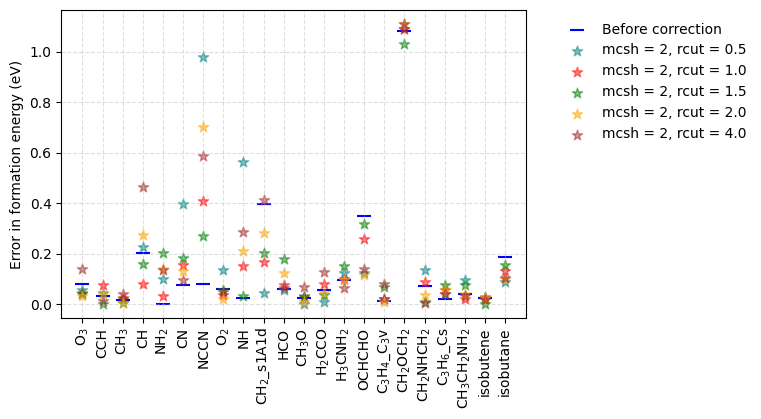

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(molecules_list, pbe_error, label='Before correction', color='blue', marker='_',s=90)
plt.scatter(molecules_list, corr_error_0_5, label='mcsh = 2, rcut = 0.5', color='teal', marker='*',s=60, alpha=0.5)
plt.scatter(molecules_list, corr_error_0_1, label='mcsh = 2, rcut = 1.0', color='r', marker='*',s=60, alpha=0.5)
plt.scatter(molecules_list, corr_error_0_15, label='mcsh = 2, rcut = 1.5', color='g', marker='*',s=60, alpha=0.5)
plt.scatter(molecules_list, corr_error_0_2, label='mcsh = 2, rcut = 2.0', color='orange', marker='*',s=60, alpha=0.5)
plt.scatter(molecules_list, corr_error_0_4, label='mcsh = 2, rcut = 4.0', color='brown', marker='*',s=60, alpha=0.5)

#plt.scatter(molecules_list, corr_error_model_2, label='After correction (Model 2)', color='red', marker='*',s=60, alpha=0.6)
# Rotating x-axis labels by 90 degrees
plt.xticks(rotation=90)
plt.legend(frameon=False, )
plt.grid(True, linestyle='--', alpha=0.4)
plt.ylabel("Error in formation energy (eV)")
#plt.yscale("log")
plt.legend(loc="upper right", bbox_to_anchor=(1.5,1),frameon=False)
#plt.savefig("unseen_molecules.png", dpi=600, bbox_inches="tight")